<a href="https://colab.research.google.com/github/AjayKumar22633/CNN_TransferLearning_Brain_Cancer/blob/main/CNN_Brain_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Author: Ajay Kumar Singha
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [ ]:
torch.manual_seed(42)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
df = '/content/drive/MyDrive/Colab Notebooks/meningioma', '/content/drive/MyDrive/Colab Notebooks/glioma', '/content/drive/MyDrive/Colab Notebooks/pituitary', '/content/drive/MyDrive/Colab Notebooks/notumor'

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"using' device: {device}")

using' device: cuda


In [ ]:
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

paths, raw_labels = [], []
for folder in df:
  cls = os.path.basename(folder)
  for f in sorted(os.listdir(folder)):
    if f.lower().endswith(('.jpg', '.jpg', '.png')):
      paths.append(os.path.join(folder,f))
      raw_labels.append(cls)
le = LabelEncoder()
labels = le.fit_transform(raw_labels)
print(dict(zip(le.classes_, np.bincount(labels))))

{np.str_('glioma'): np.int64(1400), np.str_('meningioma'): np.int64(1400), np.str_('notumor'): np.int64(1400), np.str_('pituitary'): np.int64(1400)}


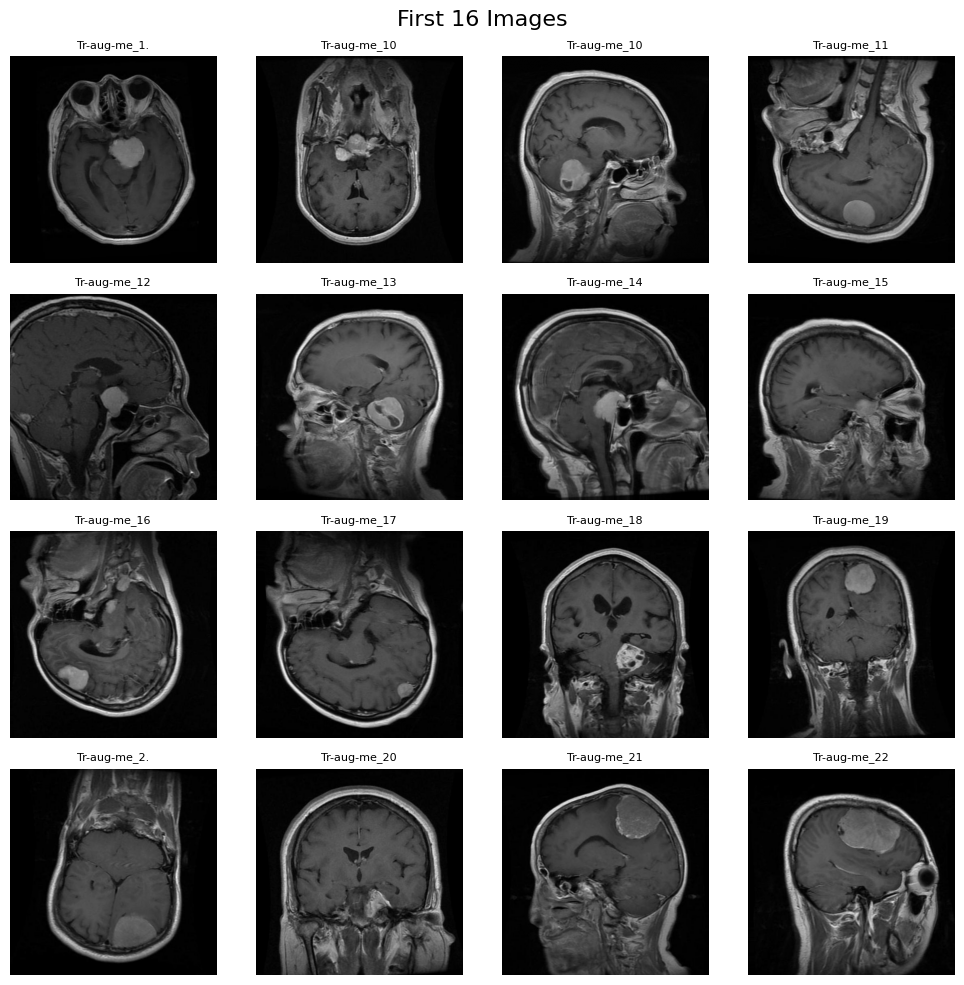

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Collect the first 16 image paths from the folders in df
image_paths = []
for folder in df:
    for fname in sorted(os.listdir(folder)):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(folder, fname))
            if len(image_paths) >= 16:
                break
    if len(image_paths) >= 16:
        break

# Plot the images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)
for ax, img_path in zip(axes.flat, image_paths):
    img = Image.open(img_path)
    ax.imshow(img, cmap='gray')
    ax.set_title(os.path.basename(img_path)[:12], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
#for import figure dataset file
import os
from sklearn.model_selection import train_test_split

files = []
paths = []
labels = []

# Loop through each folder in the df tuple to collect files, paths, and labels
for folder in df:
    folder_files = sorted(os.listdir(folder))
    for f in folder_files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            files.append(f)
            paths.append(os.path.join(folder, f))
            labels.append(f.split('_')[0])

print("Sample files:", files[:10])
print("Unique labels found:", set(labels))

Sample files: ['Tr-aug-me_1.jpg', 'Tr-aug-me_10.jpg', 'Tr-aug-me_100.jpg', 'Tr-aug-me_11.jpg', 'Tr-aug-me_12.jpg', 'Tr-aug-me_13.jpg', 'Tr-aug-me_14.jpg', 'Tr-aug-me_15.jpg', 'Tr-aug-me_16.jpg', 'Tr-aug-me_17.jpg']
Unique labels found: {'Tr-me', 'Tr-no', 'Tr-aug-me', 'Tr-pi', 'Tr-gl'}


In [ ]:
#train test split
x_train, x_test, y_train, y_test = train_test_split(
    paths, labels, test_size=0.2, random_state=42, stratify=labels
)
print(len(x_train), len(x_test))

4480 1120


In [ ]:
#load images into arrays
import numpy as np
from PIL import Image
def load_images(path_list, size=(128, 128)):
  imgs = []
  for p in path_list:
    img = Image.open(p).convert('L').resize(size)
    imgs.append(np.array(img))
  return np.array(imgs)

In [ ]:
#transformations
from torchvision.transforms import transforms
custom_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
from PIL import Image
import numpy as np
class customDataset(Dataset):
  def __init__(self, features, labeels, transforms):
    self.features = features
    self.labels = labels
    self.transform = transform
  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):

    #resize to (28,28)
    image = self.fetures[index].reshape(28,28)

    #change datatype to np.uint8
    image = image.astype(np.uint8)

    #cahnge black&white to color (H,W,C)---> (C,H,W)
    np.stack([image]*3, axis=-1)

    #convert array to PIL image
    image = Image.fromarray(image)

    #apply transforms
    image = self.transform(image)

    #return
    return image, torch.tensor(self.label[index], dtype=torch.long)


In [ ]:
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

# Redefine CustomDataset to correctly load images from paths as RGB to match 3-channel normalization
class CustomDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
       self.image_paths = image_paths
       self.labels = torch.tensor(labels, dtype=torch.long)
       self.transform = transform

    def __len__(self):
       return len(self.image_paths)

    def __getitem__(self, index):
       # Load image from path list and convert to RGB (3 channels)
       img_path = self.image_paths[index]
       image = Image.open(img_path).convert('RGB')

       if self.transform:
           image = self.transform(image)
       else:
           # Fallback resize and conversion to tensor if no transform is provided
           image = image.resize((128, 128))
           image = torch.tensor(np.array(image) / 255.0, dtype=torch.float32).permute(2, 0, 1)

       return image, self.labels[index]

# Re-split labels to restore y_train and y_test to their original string state
_, _, y_train_orig, y_test_orig = train_test_split(
    paths, labels, test_size=0.2, random_state=42, stratify=labels
)

# Fit and transform safely on original string labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_orig)
y_test_enc = le.transform(y_test_orig)

# Import custom_transform if defined previously
try:
    transform_to_use = custom_transform
except NameError:
    transform_to_use = None

# Instantiate the custom datasets properly with image path lists and the transform pipeline
train_dataset = CustomDataset(x_train, y_train_enc, transform=transform_to_use)
test_dataset = CustomDataset(x_test, y_test_enc, transform=transform_to_use)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

x0, y0 = train_dataset[0]
print(f"Sample shape: {x0.shape}, label: {y0}")

Train dataset size: 4480
Test dataset size: 1120
Sample shape: torch.Size([3, 224, 224]), label: 1


In [ ]:
#test dataset obj
test_dataset = CustomDataset(x_test, y_test_enc)

In [ ]:
#train test loader
train_loader = DataLoader(train_dataset, batch_size=138, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=138, shuffle=False)
len(train_loader)

33

In [ ]:
#fetch the pretrained model
import torchvision.models as models
vgg16 = models.vgg16(pretrained=True)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 83.2MB/s]


In [ ]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
for param in vgg16.features.parameters():
  param.requires_grad=False

In [ ]:
vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 10)
)

In [ ]:
#to move model gpu
vgg16 = vgg16.to(device)


In [ ]:
#learning rate & epochs
epochs = 100
learning_rate = 0.01

In [ ]:
#Loss function
Criterion = nn.CrossEntropyLoss()
#optimizer
optimizer = optim.Adam(vgg16.classifier.parameters(), lr = learning_rate, weight_decay=1e-4)

In [ ]:
# Redefine the NN class with correct indentation for the 'forward' method
class MyNN(nn.Module):
  def __init__(self, input_features):
    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(input_features, 32, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(32, 64, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2, stride=2),
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        # Since input is (128, 128), after two MaxPool2d (stride 2), height/width is 128 / 2 / 2 = 32
        nn.Linear(64 * 32 * 32, 128),
        nn.ReLU(),
        nn.Dropout(p=0.4),

        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(p=0.4),

        nn.Linear(64, 10)
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

# Instantiate the model with 1 input channel (grayscale)
Model = MyNN(1).to(device)

# Redefine the optimizer to attach to the new model parameters
optimizer = optim.SGD(Model.parameters(), lr=learning_rate)

# training loop
for epoch in range(epochs):
  total_epoch_loss = 0
  for batch_features, batch_labels in train_loader:
    # Move data to device
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    # Forward pass
    outputs = vgg16(batch_features)
    loss = Criterion(outputs, batch_labels)

    # Backward pass and optimization step
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Accumulate loss
    total_epoch_loss += loss.item()

  # Calculate and print epoch average loss
  avg_loss = total_epoch_loss / len(train_loader)
  if (epoch + 1) % 10 == 0 or epoch == 0:
    print(f'Epoch: {epoch + 1}, Loss: {avg_loss:.4f}')

Epoch: 1, Loss: 2.3255
Epoch: 10, Loss: 2.3258
Epoch: 20, Loss: 2.3260
Epoch: 30, Loss: 2.3257
Epoch: 40, Loss: 2.3258
Epoch: 50, Loss: 2.3254
Epoch: 60, Loss: 2.3258
Epoch: 70, Loss: 2.3258
Epoch: 80, Loss: 2.3257
Epoch: 90, Loss: 2.3256


In [ ]:
Model.eval()

MyNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=65536, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
#evaluation on test data
total = 0
correct = 0
with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    # Move input and label tensors to the same device as the model
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    outputs = vgg16(batch_features)
    __, predicted = torch.max(outputs, 1)
    total = total + batch_labels.shape[0]
    correct = correct + (predicted == batch_labels).sum().item()
print(correct / total)

0.09910714285714285


In [ ]:
#evaluation on train data
total = 0
correct = 0
with torch.no_grad():
  for batch_features, batch_labels in train_loader:
    # Move input and label tensors to the same device as the model
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    outputs = vgg16(batch_features)
    __, predicted = torch.max(outputs, 1)
    total = total + batch_labels.shape[0]
    correct = correct + (predicted == batch_labels).sum().item()
print(correct / total)

0.08816964285714286


In [ ]:
#prediction
import numpy as np
import torch
from PIL import Image

def predict_image(path):
  # Load image as RGB (3 channels) instead of Grayscale 'L'
  img = Image.open(path).convert('RGB')

  # Apply custom_transform if it is defined to resize, crop, and normalize correctly
  if 'custom_transform' in globals():
    x = custom_transform(img)
  else:
    # Fallback to manual preprocessing
    img = img.resize((224, 224))
    x = torch.tensor(np.array(img) / 255.0, dtype=torch.float32).permute(2, 0, 1)

  # Add batch dimension and move to device
  x = x.unsqueeze(0).to(device)

  vgg16.eval()
  with torch.no_grad():
    out = vgg16(x)
    probs = torch.softmax(out, dim=1)[0]
    pred = probs.argmax().item()
  return le.classes_[pred], probs[pred].item()

try:
  label, conf = predict_image('/content/drive/MyDrive/Colab Notebooks/Tr-no_6.jpg')
  print(label, f"{conf:.1%}")
except Exception as e:
  print(e)

Tr-me 11.6%
